<a href="https://colab.research.google.com/github/jgmsantos/minicurso_queimadas_2026/blob/main/Aula_1_ex03_focos_anual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

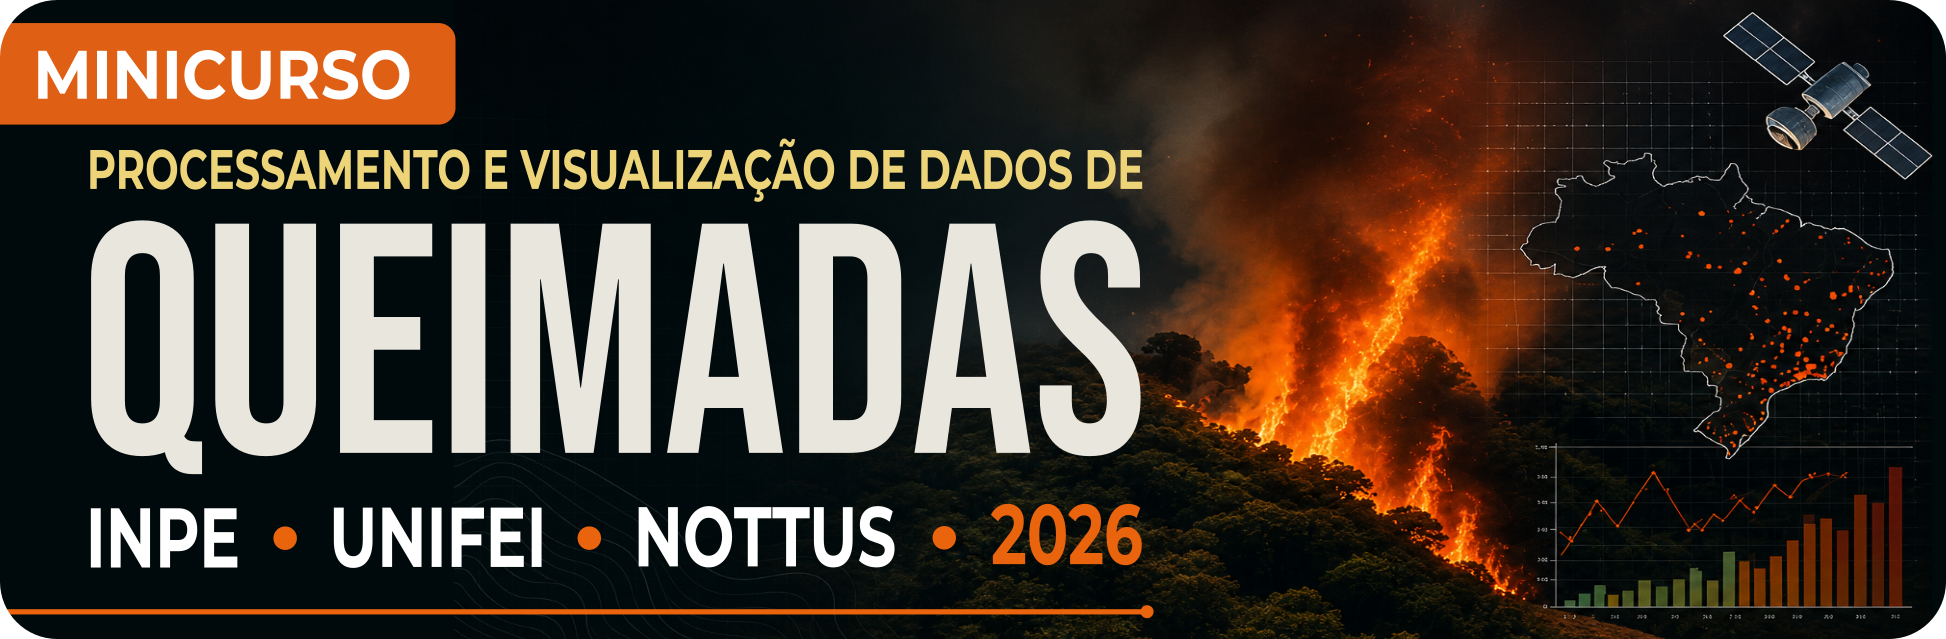

🎯**Objetivo:**


**Processar e visualizar** arquivos anuais e mensais de focos de queimadas do satélite **AQUA_M-T** sobre o Brasil utilizando dados gratuitos do Programa Queimadas do INPE. Serão utilizados dados desde 2003 até julho de 2026.


---


🧑**Palestrante/Tutor**

Dr. Guilherme Martins - Nottus Meteorologia

✉ guilherme.martins@nottus.com.br | jgmsantos@gmail.com

🌎 https://github.com/jgmsantos

🌎 https://guilherme.readthedocs.io/en/latest/


---


✅**Aulas ministradas**

- Aula_1_ex01: https://colab.research.google.com/drive/1mznslPhwRJlc75Vc2oJM-JR0g3M0K9b5?usp=sharing
- Aula_1_ex02: https://colab.research.google.com/drive/1Xehetg_R3WMwq1E889q7XgKbLAceur6s?usp=sharing

---

📚**Material de apoio sobre Python**

https://guilherme.readthedocs.io/en/latest/pages/tutoriais/python.html

---

🎲**Dados utilizados no formato csv**
- Focos anuais:
  - https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref
- Focos mensais de 2026:
  - https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil

---

✅**Atividades a serem desenvolvidas**
1. Aprender a importar bibliotecas
1. Montar o drive para ler/salvar arquivos
1. Acessar os dados anuais e mensais de focos
1. Explorar os dados
1. Concatenar os arquivos
1. Processar e visualizar por estado
   - Filtrar datas
   - Filtrar área de interesse (município, estado ou bioma)
   - Calcular algumas métricas
1. Processar e visualizar o dado mensal
   -. Calcular acumulado mensal
   -. Calcular média mensal
   -. Heatmap
1. Processar e visualizar o dado anual
   - Calcular o acumulado anual
   - Calcular porcentagem em relação à média
   - Calcular a variação percentual do ano corrente em relação ao ano anterior

---

❗**Importante**

- Necessário possuir uma conta do Gmail.
- Salvar este código no seu Google Drive. Basta clicar em **Arquivo** (canto superior esquerdo) e depois em **Salvar uma cópia no drive** e fazer o login numa conta Google.
---

## Importação de bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Para visualização de dados baseada no Matplotlib.
import os # Para criar diretórios para salvar as figuras.
import numpy as np # Usado para operações matemáticas.

# Montar o drive para ler/salvar arquivos que estão no seu Google Drive.
# Não precisa alterar nada, é assim mesmo.
from google.colab import drive
drive.mount("/content/drive")

In [ ]:
# Local para salvar as figuras.
# ALTERAR AQUI APONTANDO PARA A PASTA "figuras".
diretorio_figuras = "/content/drive/MyDrive/cursos/queimadas_2026/scripts/figuras"

# Cria o diretório acima caso ele não exista.
os.makedirs(diretorio_figuras, exist_ok=True)

## Processamento dos dados anuais

Os dados anuais correspondem aos anos entre 2003 e 2025.

In [ ]:
# Tempo de execução: 00:01:20.

# Colunas dos arquivos anuais: 9 colunas.
# id_bdq,foco_id,lat,lon,data_pas,pais,estado,municipio,bioma

# https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref

# nome do arquivo: 	focos_br_ref_2003.zip

# Dados desde: 2003 até 2025.

# URL dos arquivos anuais do satélite AQUA_M-T.
url_anual = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/anual/Brasil_sat_ref"

lista_anual = [] # Lista vazia.

# Serão utilizadas apenas 6 colunas.
colunas_interesse = [
    "lat", "lon", "data_pas", "estado", "municipio", "bioma"
  ]

# Percorre todos os anos disponíveis.
# Ao usar range, sempre colocar um ano adicional.
# Como será feito até 2025, então, o último ano é 2026.
# Se colocar 2025, será feito até 2024.
for ano in range(2003, 2026):

  print(f"Processando o ano: {ano}")

  # Nome do arquivo que está na URL acima.
  nome_arquivo = f"focos_br_ref_{ano}.zip"

  # URL com o nome do arquivo que será processado.
  url_com_arquivo = f"{url_anual}/{nome_arquivo}"

  try:
    # Leitura de cada arquivo selecionando apenas as colunas de interesse e
    # definindo a coluna "data_pas" como Datetime (parse_dates).
    df_tmp = pd.read_csv(
        url_com_arquivo,
        compression="zip", # Isso porque o arquivo está zipado.
        usecols=colunas_interesse,
        parse_dates=["data_pas"]
    )

    # Se df_tmp está vazio (empty).
    if df_tmp.empty:
      print(f"O DataFrame está vazio para o ano: {ano}")
      continue

    # Lista de DataFrames.
    lista_anual.append(df_tmp)

  except Exception as e:

    print(f"Erro ao ler {nome_arquivo}: {e}")

# Concatena a lista com todos os DataFrames em um único DataFrame.
# https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_anual = pd.concat(lista_anual, ignore_index=True)

In [ ]:
# Visualiza o DataFrame.
df_anual

In [ ]:
# Verifica o tipo de dado.
df_anual.info()

In [ ]:
# Ordena as datas cronologicamente.
df_anual = df_anual.sort_values("data_pas")

In [ ]:
# Visualiza o DataFrame.
df_anual

## Processamento dos dados mensais para o ano de 2026 para o satélite AQUA_M-T

Nestes arquivos estão todos os satélites.

In [ ]:
# Tempo de execução: 00:00:25.

# Colunas dos arquivos anuais: 16 colunas.
# id,lat,lon,data_hora_gmt,satelite,municipio,estado,pais,municipio_id,estado_id,pais_id,numero_dias_sem_chuva,precipitacao,risco_fogo,bioma,frp

# https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil

# nome do arquivo: 	focos_mensal_br_202601.csv

# Dados desde: 202301-atual.

# URL dos arquivos mensais com todos os satélites somente para o Brasil.
url_mensal = "https://dataserver-coids.inpe.br/queimadas/queimadas/focos/csv/mensal/Brasil"

lista_mensal = [] # Lista vazia.

# Serão usadas 7 colunas.
colunas_interesse = [
    "lat" ,"lon" ,"data_hora_gmt" ,"satelite" ,"municipio" ,"estado" ,"bioma"
  ]

# Loop ao longo dos meses.
for mes in range(1, 8):

  print(f"Processando o mes {mes:02d} de 2026")

  # Nome do arquivo que está na URL.
  nome_arquivo = f"focos_mensal_br_2026{mes:02d}.csv"

  # URL com o nome do arquivo que será processado.
  url_com_arquivo = f"{url_mensal}/{nome_arquivo}"

  try:
    # Leitura de cada arquivo selecionando apenas as colunas de interesse e
    # definindo a coluna "data_hora_gmt" como Datetime.
    df_tmp = pd.read_csv(
        url_com_arquivo,
        usecols=colunas_interesse,
        parse_dates=["data_hora_gmt"]
    )

    # Se df_tmp está vazio (empty).
    if df_tmp.empty:
      print(f"O DataFrame está vazio para o mes: {mes:02d}")
      continue

    # Lista de DataFrames. Ou seja, empilha os DataFrames.
    lista_mensal.append(df_tmp)

  except Exception as e:
    print(f"Erro ao ler {nome_arquivo}: {e}")

# Concatena todos os DataFrames em um único DataFrame.
# https://pandas.pydata.org/docs/reference/api/pandas.concat.html
df_mensal = pd.concat(lista_mensal)

In [ ]:
# Visualiza o DataFrame.
df_mensal

In [ ]:
# Verifica o tipo de dado.
df_mensal.info()

In [ ]:
# Seleciona o satélite AQUA_M-T.
df_mensal = df_mensal[df_mensal["satelite"] == "AQUA_M-T"]

# Visualiza o DataFrame.
df_mensal

In [ ]:
# Remove a coluna satelite porque já foi selecionado o satélite AQUA_M-T.
df_mensal = df_mensal.drop(columns="satelite")

In [ ]:
# Ordena as datas cronologicamente.
df_mensal = df_mensal.sort_values("data_hora_gmt")

df_mensal

In [ ]:
# Visualiza o nome das colunas de df_anual.
df_anual.columns

In [ ]:
# Visualiza o nome das colunas de df_mensal.
df_mensal.columns

## Concatenar os DataFrames anual e mensal

Uma vez gerados o df_anual e o df_mensal, a ideia é concatená-los em um único DataFrame (2003 até 2026). Para isso, é necessário que as colunas obrigatoriamente tenham o mesmo nome, a ordem delas não influencia.

In [ ]:
# Cria uma cópia dos DataFrames para evitar reprocessamento dos dados.
df_anual_copia = df_anual.copy()
df_mensal_copia = df_mensal.copy()

# Reordena as colunas do df_anual para a mesma ordem do df_mensal.
df_anual_copia = df_anual_copia[["lat", "lon", "data_pas", "municipio", "estado", "bioma"]]

# Visualiza o DataFrame.
df_anual_copia

In [ ]:
# Renomea as colunas do df_anual_copia para os mesmos nomes do df_mensal_copia.
# O único nome diferente é a coluna da hora.
# No anual é "data_pas" e no mensal é "data_hora_gmt".
# Logo, alterar de "data_pas" para "data_hora_gmt".
df_anual_copia = df_anual_copia.rename(columns={"data_pas": "data_hora_gmt"})

# Visualiza o DataFrame df_anual_copia.
df_anual_copia

Apenas checando se os nomes das colunas dos dois DataFrames são iguais.

In [ ]:
df_anual_copia.columns

In [ ]:
df_mensal_copia.columns

In [ ]:
# Concatena os dois DataFrames. O "pd.concat" concatena pelos nomes das colunas
# e não pelas posição delas.
df_final = pd.concat([df_anual_copia, df_mensal_copia], ignore_index=True)

# Renomeia as colunas para nomes definidos pelo usuário.
df_final.columns = ["Lat", "Lon", "Data", "Municipio", "Estado", "Bioma"]

# Visualiza o DataFrame.
df_final

## O que fizemos até aqui?

- Processamento dos arquivos anuais (2003 a 2025) somente do satélite AQUA_M-T.
- Processamento dos arquivos mensais do ano 2026 com todos os satélites.
  - Seleção do satélite AQUA_M-T.
- Concatenação dos dois DataFrames (anual e mensal).
  - Padronização dos nomes e da ordem das colunas do DataFrame anual de acordo com o DataFrame mensal.

## O que queremos fazer?

- realizar filtragem por município, estado ou bioma.
- acumulado em diferentes escalas temporais (diária, mensal, sazonal e anual)
- visualização.

## Processamento e visualização

As análises e as visualizações utilizarão a coluna "Estado" do "df_final" (DataFrame concatenado com todos os anos desde 2003 até julho de 2026).

O que faremos inicialmente?

- reproduzir alguns resultados (tabelas e figuras) gerados pelo Programa Queimadas do INPE.
  - https://data.inpe.br/queimadas/situacao_atual
  - Focos por estado
  - acumulado desde **01/07** até o dia de ontem.
  - acumulado desde **01/01/2026** até o dia de ontem.

### Filtragem de datas

O **ano de 2024** foi escolhido porque houve um **aumento expressivo na quantidade de focos de queimadas**. Para se ter ideia, no Brasil em 2023 foram registrados 29.651 focos contra 44.951 em 2024, isso representa um **aumento de ~52%** de um ano para o outro.

In [ ]:
data_inicio = "2024-01-01" # Data de início de interesse.
data_fim = "2024-12-31" # Data de fim de interesse.

# Filtro para o intervalo de datas.
# O operador ">=" significa maior ou igual a.
# O operador "<=" significa menor ou igual a.
# O "&" é o operador AND lógico do Pandas (elemento por elemento).
# Ele exige que as duas condições sejam verdadeiras ao mesmo tempo.
filtro_data = (df_final["Data"].dt.date >= pd.to_datetime(data_inicio).date()) & \
              (df_final["Data"].dt.date <= pd.to_datetime(data_fim).date())

# Aplica o filtro para o intervalo de datas de interesse.
df_data_focos = df_final[filtro_data]

# Visualiza o DataFrame para o intervalo de datas selecionado.
df_data_focos

### Seleção da coluna de interesse e acumulado por estado

❗**Observação:** Na próxima aula, o Prof. Enrique dará ênfase ao Estado de São Paulo no mês de agosto de 2024. No final deste mês, teve o evento que ficou conhecido como o **dia do fogo** (23/08/2024 = 1.889 focos). Ele usará informações satelitais em alta resolução, da ordem de 10m do Sentinel.

In [ ]:
# NOME DA COLUNA que está no DataFrame.
coluna_interesse = "Estado"

# Contabiliza a quantidade de focos.
contagem_focos = df_data_focos.groupby(by=coluna_interesse).Estado.count()

# Cria um DataFrame para armazenar os resultados.
# "Estado" e "#Focos" são nomes definidos pelo usuário de acordo com a escolha de "coluna_interesse".
df_contagem = pd.DataFrame({"Estado":contagem_focos.index, "#Focos":contagem_focos.values})

# Visualiza o DataFrame. O RESULTADO É APRESENTADO NA ORDEM ALFABÉTICA.
df_contagem

In [ ]:
# Ordena os valores dos focos.
df_ordenado = df_contagem.sort_values(by="#Focos", ascending=True)

# Reinicializa o index.
df_ordenado.reset_index(drop=True, inplace=True)

# Visualiza o DataFrame.
df_ordenado

In [ ]:
# A primeira letra de cada estado será em maiuscúla (title()).
df_ordenado["Estado"] = df_ordenado["Estado"].str.title()

# Visualiza o DataFrame com os valores da coluna "Estado" em title case (em maiuscúla).
df_ordenado

#### Visualização

In [ ]:
# Cria o gráfico de barras.
plt.figure(figsize=(12, 7))

# Plot dos focos por estado.
plt.barh(df_ordenado["Estado"], df_ordenado["#Focos"], color="red")

# Rotaciona os rótulos do eixo x para o caso de "plt.bar" (barra vertical).
#plt.xticks(rotation=90)

# Adiciona título e rótulos.
plt.ylabel("Estado")
plt.xlabel("Número de Focos")
plt.title("Número de Focos de Queimadas por Estado")

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-01focos_por_estado.png", dpi=300)

# Mostra o gráfico
plt.show()

### Cálculo percentual por estado

In [ ]:
# Cálculo percentual na janela de dados selecionada no início do script.

# Calcula o total de focos.
total_geral_focos = df_ordenado["#Focos"].sum()

# Cria uma coluna chamada "%Focos" para calcula a porcentagem de
# focos e arredondar para duas casas decimais.
df_ordenado["%Focos"] = ((df_ordenado["#Focos"] / total_geral_focos) * 100).round(2)

# Visualiza o DataFrame com a nova coluna de porcentagem.
df_ordenado

In [ ]:
# É o mesmo código da figura anterior.
# Aqui usa-se: df_ordenado["%Focos"] em vez de df_ordenado["#Focos"]

# Cria o gráfico de barras.
plt.figure(figsize=(12, 7))

# Plot percentual dos focos.
plt.barh(df_ordenado["Estado"], df_ordenado["%Focos"], color="blue")

# Adiciona título e rótulos.
plt.ylabel("Estado")
plt.xlabel("Porcentagem (%)")
plt.title("Porcentagem de Focos de Queimadas por Estado")

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-02focos_por_estado_porcentual.png", dpi=300)

# Mostra o gráfico
plt.show()

### Estatística descritiva dos estados

In [ ]:
df_ordenado.describe()

### Mostrar o rank dos estados

In [ ]:
# Mostra o rank dos estados com as MAIORES quantidades de focos.
df_ordenado.nlargest(3, "#Focos")

In [ ]:
# Mostra o rank dos estados com as MENORES quantidades de focos.
df_ordenado.nsmallest(3, "#Focos")

Para realizar as demais análises, será criada uma cópia do DataFrame

In [ ]:
# Visualiza o DataFrame para o intervalo de datas selecionado.
df_final_copia = df_final.copy()

# Visualiza o DataFrame.
df_final_copia

### Processamento e visualização mensal

Objetivo: Gerar o acumulado mensal dos focos de queimadas para o estado selecionado.

#### Acumulado mensal

In [ ]:
# Seleciona o estado de interesse.
nome_estado = "PARÁ"
filtro_interesse = df_final_copia["Estado"] == nome_estado

# Aplica o filtro.
df_estado = df_final_copia[filtro_interesse]

# visualiza o DataFrame.
df_estado

In [ ]:
# Verifica o tipo do dado.
df_estado.info()

In [ ]:
# Calcula o acumulado mensal de focos de queimadas para cada ano.
# O "to_period" converte para períodos específicos (meses, anos, estação dentre outros).
# "M" = converte para mês.
df_acumulado_mensal = df_estado.groupby(by=df_estado["Data"].dt.to_period("M")).Estado.size()

# Visualiza o DataFrame.
df_acumulado_mensal

In [ ]:
# Formatação do gráfico.
fig = plt.figure(figsize=(15, 7))

# Cria o gráfico de barras vertical.
plt.bar(
    df_acumulado_mensal.index.astype(str),  # Converte o índice de período para string.
    df_acumulado_mensal.values,             # Valores do acumulado mensal.
    color="lightcoral"                      # Cor vermelho claro.
)

# Adiciona título e rótulos aos eixos.
plt.title(f"Acumulado Mensal de Focos de Queimadas - {nome_estado}")
plt.xlabel("Data")
plt.ylabel("Número de Focos")

# Gera posições e rótulos para cada x anos.
x_anos = 1 # Intervalo dos rótulos do eixo x.
tick_positions = []
tick_labels = []
start_year = df_acumulado_mensal.index.year[0] # Pega o primeiro ano do índice
for i, period in enumerate(df_acumulado_mensal.index):
    # Exibe o rótulo apenas para o mês de janeiro dos anos múltiplos de x anos, a partir do ano inicial
    if period.month == 1 and (period.year - start_year) % x_anos == 0:
        tick_positions.append(i)
        tick_labels.append(str(period))

# Plot os xtick em cada posição.
plt.xticks(tick_positions, tick_labels, rotation=90)

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-03acumulado_mensal.png", dpi=300)

# Mostra o gráfico
plt.show()

#### Média mensal

- A partir da média mensal, é possível oberservar o comportamento médio dos focos.
- Para ser considerada uma climatologia, são necessários 30 anos de dados.

In [ ]:
# Seleciona o período de interesse para realizar a média mensal considerando 2003 a 2025.
df_media_mensal = df_acumulado_mensal.copy()

# Seleção do período para fazer a média.
# Aconselhável que o ano tenha todos os meses.
df_media_mensal = df_media_mensal.loc["2003-01":"2025-12"]

# Calcula a média mensal do período 2003-2025.
df_media_mensal = df_media_mensal.groupby(df_media_mensal.index.month).mean().round(0).astype(int)

# Renomeia "Data" para "Mês" e "Estado" para "#Focos".
df_media_mensal.index.name = "Mês"
df_media_mensal.name = "#Focos"

# Substitui os meses no formato 1, 2, 3, ..., 12 para Jan, Fev, ..., Dez.
meses_map = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}
df_media_mensal = df_media_mensal.rename(index=meses_map)

# Visualiza a média mensal com o index reinicializado.
df_media_mensal.reset_index()

In [ ]:
# Formatação do gráfico.
plt.figure(figsize=(12, 7))

# Cria o gráfico de barras vertical.
bars = plt.bar(
    df_media_mensal.index.astype(str),  # Converte o índice de mês para string para o eixo X
    df_media_mensal.values,             # Valores da média mensal.
    color="lightcoral"                  # Cor vermelho claro.
)

# Adiciona os rótulos de dados nas barras.
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=9)

# Adiciona título e rótulos aos eixos.
plt.title(f"Média Mensal de Focos de Queimadas (2003-2025) - {nome_estado}")
plt.xlabel("Mês")
plt.ylabel("Número Médio de Focos")

# Rotaciona os rótulos do eixo X se necessário.
plt.xticks(rotation=0)

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-04media_mensal.png", dpi=300)

# Mostra o gráfico
plt.show()

#### Heatmap

Será criada uma tabela pivot (colunas são os meses e as linhas são os anos).

In [ ]:
# Cria uma cópia do DataFrame e reinicializa o index.
df_tabela_pivot = df_acumulado_mensal.copy().reset_index()

# Renomeia de "Estado" para "TotalFocos".
df_tabela_pivot = df_tabela_pivot.rename(columns={"Estado": "TotalFocos"})

# Cria as colunas "Ano" e "Mês" para serem utilizadas na tabela pivot.
df_tabela_pivot["Ano"] = df_tabela_pivot["Data"].dt.year
df_tabela_pivot["Mês"] = df_tabela_pivot["Data"].dt.month

# Cria a tabela pivot e preenche com valor zero o mês com dados faltantes.
df_tabela_pivot = df_tabela_pivot.pivot_table(
    index="Ano",
    columns="Mês",
    values="TotalFocos",
    aggfunc="sum",
    fill_value=0
)

# Mapeamento para substituir os meses no formato 1, 2, 3, ..., 12 para
# Jan, Fev, ..., Dez.
# Quando for 1 altera para Jan, 2 para Fev e assim por diante.
meses_map = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

# Mapeamento dos meses.
df_tabela_pivot = df_tabela_pivot.rename(columns=meses_map)

# Visualiza a tabela pivot.
df_tabela_pivot

In [ ]:
# Criar o heatmap.

plt.figure(figsize=(15, 8))

# Plot do heatamp.
sns.heatmap(
    df_tabela_pivot,
    cmap="Reds",  # Tabela de cores: https://matplotlib.org/stable/users/explain/colors/colormaps.html
    linewidths=0.5,
    annot=True,
    fmt="d"
  )

# Adiciona título e rótulos aos eixos
plt.title(f"Heatmap de Focos de Queimadas - {nome_estado}")
plt.xlabel("Mês")
plt.ylabel("Ano")

# Salva a figura
plt.savefig(f"{diretorio_figuras}/ex03-05heatmap.png", dpi=300)

# Mostra o gráfico
plt.show()

#### Acumulado anual

> Definir o intervalo de dias para todos os anos para efeito de compararação!!!

In [ ]:
# Criau uma cópia do DataFrame.
df_tmp_anual = df_estado.copy()

# Seleciona o mesmo período de dias para cada um dos anos (de 2003 a 2026).
# Exemplo: 2003-01-01 a 2023-07-25; 2004-01-01 a 2024-07-25; ..., 2026-01-01 a 2026-07-25
# Isso é feito para que a comparação entre os anos seja equivalente.
#df_tmp_anual["Data"] = pd.to_datetime(df_tmp_anual["Data"]) # Caso a coluna não fosse Datetime.

# Define o formato da data como MM-DD.
md = df_tmp_anual["Data"].dt.strftime("%m-%d")

# Aplica o filtro de datas para cada ano.
df_tmp_anual_periodo = df_tmp_anual[(md >= "01-01") & (md <= "07-22")]

# Visualiza o DataFrame.
df_tmp_anual_periodo

In [ ]:
# Calcular o acumulado anual de focos de queimadas para cada ano.
# O "to_period" converte para períodos específicos (meses, anos, estação dentre outros).
# Y = converte para ano.
df_acumulado_anual = df_tmp_anual_periodo.groupby(by=df_tmp_anual_periodo["Data"].dt.to_period("Y")).Estado.size().astype(int)

# Visualização mensal dos focos de queimadas.
df_acumulado_anual

In [ ]:
# Resetar o index.
df_acumulado_anual = df_acumulado_anual.reset_index()

# Renomear as colunas.
df_acumulado_anual.columns = ["Ano", "TotalFocos"]

# Visualizar o DataFrame.
df_acumulado_anual

In [ ]:
# Tipo do dado.
df_acumulado_anual.info()

In [ ]:
# Cálculo percentual considerando todos os anos.

# Selecionar os anos entre 2003 e 2026.
#df_acumulado_anual_2003_2026 = df_acumulado_anual[df_acumulado_anual["Ano"].dt.year.between(2003, 2026)]

#df_acumulado_anual_2003_2026

In [ ]:
# Calculo da média dos focos entre 2003 e 2026.
media_anual = df_acumulado_anual["TotalFocos"].mean().round(0).astype(int)

# Cria uma coluna chamada "%Focos" para calcular a porcentagem de focos.
df_acumulado_anual["%Focos"] = ((df_acumulado_anual["TotalFocos"] / media_anual) * 100).round(0).astype(int)

# Subtrai de 100 para saber se houve aumento ou redução dos focos para cada ano.
df_acumulado_anual["%Focos"] = df_acumulado_anual["%Focos"] - 100

# Visualiza o DataFrame.
df_acumulado_anual

In [ ]:
# Formatação do gráfico.
plt.figure(figsize=(15, 8))

# Cria o gráfico de barras vertical com a cor vermelho claro.
bars = plt.bar(
    df_acumulado_anual["Ano"].astype(str), # Converte o ano para string para o rótulo do eixo X
    df_acumulado_anual["TotalFocos"],
    color="lightcoral"
)

# Adiciona os valores de focos em cada coluna do gráfico.
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, round(yval, 0), ha="center", va="bottom", fontsize=9)

# Adiciona uma linha horizontal com o valor da média anual.
plt.axhline(media_anual, color="blue", linestyle="--", label=f"Média Anual: {media_anual:.0f} focos")

# Calcula os percentis 95 e 99 diretamente da coluna "TotalFocos".
percentil_95_totalfocos = df_acumulado_anual["TotalFocos"].quantile(0.95).round(0).astype(int)
percentil_99_totalfocos = df_acumulado_anual["TotalFocos"].quantile(0.99).round(0).astype(int)

# Adiciona linhas horizontais para o percentil 95 e 99 (TotalFocos).
plt.axhline(percentil_95_totalfocos, color="green", linestyle=":", label=f"Percentil 95: {percentil_95_totalfocos} Focos")
plt.axhline(percentil_99_totalfocos, color="purple", linestyle=":", label=f"Percentil 99: {percentil_99_totalfocos} Focos")

# Adiciona título e rótulos aos eixos.
plt.title(f"Acumulado Anual de Focos de Queimadas (2003-2026) - {nome_estado}")
plt.xlabel("Ano")
plt.ylabel("Número de Focos")

# Rotaciona os rótulos do eixo X para melhor visualização.
plt.xticks(rotation=45, ha="right")

# Adiciona a legenda para a linha de média e percentis.
# Ajustar o bbox_to_anchor para deslocar a legenda para baixo e para a direita.
plt.legend(loc="upper right", bbox_to_anchor=(1, 0.9))

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-06acumulado_anual.png", dpi=300)

# Mostra o gráfico.
plt.show()

In [ ]:
# Formatação do gráfico.
plt.figure(figsize=(15, 8))

# Cria o gráfico de barras condicionalmente.
# Itera sobre cada ano e seu respectivo %Focos.
bars = [] # Lista para armazenar as barras plotadas.
for index, row in df_acumulado_anual.iterrows():
    ano = str(row["Ano"].year) # Converte o ano para string para o rótulo do eixo X
    porcentagem_focos = row["%Focos"]

    if porcentagem_focos >= 0:
        # Barras vermelhas para aumento de focos.
        bars.append(plt.bar(ano, porcentagem_focos, color="lightcoral"))
    else:
        # Barras azuis para redução de focos.
        bars.append(plt.bar(ano, porcentagem_focos, color="lightblue"))

# Adiciona os valores de focos em cada coluna do gráfico.
for bar_list in bars:
    # bar_list é uma lista de um único elemento (a barra).
    bar = bar_list[0] if isinstance(bar_list, (list, tuple)) else bar_list
    yval = bar.get_height()
    # Ajusta a posição y para o texto, dependendo se o valor é positivo ou negativo
    va = "bottom" if yval >= 0 else "top"
    y_offset = 2 if yval >= 0 else -2
    plt.text(bar.get_x() + bar.get_width()/2, yval + y_offset, f"{yval}%", ha="center", va=va, fontsize=9)

# Adiciona título e rótulos aos eixos.
plt.title(f"Variação Percentual Anual de Focos de Queimadas (2003-2026) - {nome_estado}")
plt.xlabel("Ano")
plt.ylabel("Variação Percentual (%)")

# Adiciona uma linha horizontal no zero para referência.
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

# Rotaciona os rótulos do eixo X para melhor visualização.
plt.xticks(rotation=45, ha="right")

# Ajusta o layout para evitar sobreposição de elementos.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-07variacao_percentual.png", dpi=300)

# Mostra o gráfico.
plt.show()

In [ ]:
# Visualização do DataFrame.
df_acumulado_anual

In [ ]:
# Cria uma cópia do DataFrame.
df_tmp = df_acumulado_anual.copy()

# Remove a coluna "%Focos" para evitar confusão na interpretação do resultado.
df_tmp = df_tmp.drop(columns=["%Focos"])

# Visualiza o DataFrame.
df_tmp

In [ ]:
# Verifica o tipo de dado.
df_tmp.info()

In [ ]:
# Converte a coluna "Ano" para "int".
df_tmp["Ano"] = df_tmp["Ano"].dt.year.astype(int).round(2)

# Checa novamente o tipo de dado.
df_tmp.info()

In [ ]:
# O método (função) "pct_change()" calcula a variação fracionária entre o elemento atual e um elemento anterior.
# Ou seja, a diferença percentual entre o ano atual e o anterior.
# Exemplo:
# 2024 = 8.712 focos. Valor anterior.
# 2025 = 2.376 focos. Valor atual.
# Em porcentagem a mudança de 2024 para 2025 foi de -73%.
# diferenca = [Valor atual - Valor anterior]/Valor anterior
# diferenca = [2.376 - 8.712]/8.712 = -0.73 x 100% = -73%.
df_tmp["VariacaoPct"] = (df_tmp["TotalFocos"].pct_change().mul(100).round(0).fillna(0))

# Visualiza o DataFrame.
df_tmp

In [ ]:
# Monta o rótulo dos anos, exemplo: 2004-2003, 2005-2004, ..., 2026-2025 que ficarão
# no eixo x. Isso tem a ver com o cálculo feito.

# Cria a coluna "Periodo" com os valores acima.
df_tmp["Periodo"] = (df_tmp["Ano"].astype(str) + "-" + (df_tmp["Ano"] - 1).astype(str))

# Remove a primeira linha porque ela tem valor zero..
df_tmp = df_tmp.iloc[1:]

df_tmp

In [ ]:
# Formatação do gráfico.
plt.figure(figsize=(15, 8))

# Define as cores das barras.
cores = np.where(df_tmp["VariacaoPct"] >= 0, "lightcoral", "lightblue")

# Cria todas as barras de uma vez.
bars = plt.bar(
    df_tmp["Periodo"].astype(str),
    df_tmp["VariacaoPct"],
    color=cores
)

# Adiciona os valores sobre as barras.
for bar in bars:
    yval = bar.get_height()

    va = "bottom" if yval >= 0 else "top"
    y_offset = 2 if yval >= 0 else -2

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + y_offset,
        f"{int(yval)}%",
        ha="center",
        va=va,
        fontsize=9
    )

# Adiciona título e rótulos aos eixos.
plt.title(f"Variação Percentual Anual de Focos de Queimadas - {nome_estado}")
plt.xlabel("Ano")
plt.ylabel("Variação Percentual (%)")

# Linha horizontal em y = 0.
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)

# Mostra todos os anos no eixo X.
plt.xticks(rotation=45, ha="right")

# Ajusta layout.
plt.tight_layout()

# Salva a figura.
plt.savefig(f"{diretorio_figuras}/ex03-08diferenca_percentual.png", dpi=300)

# Mostra o gráfico.
plt.show()